In [39]:
import sys 
import os 
from pathlib import Path
REPO_ROOT = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(REPO_ROOT / "code"))
from analysis_of_simulation_result import * 
import matplotlib.pyplot as plt
from make_network import *
from fitting import sigmoid


with open('/volume_4/research/seongbong/flywire/geosmin_project_version_update/data/sez_neurons.pickle','rb') as f:
    sez = pickle.load(f)
sez_ids = np.concatenate(list(sez.values()))
sez_id2g = {f:g for g,fid in sez.items() for f in fid}

In [40]:

fitting_result_path = Path('/volume_4/research/seongbong/flywire/yu_desilva_geosmin_release/figure4/figure4F-K.MN9_PER_fitting')
params_opt_tarsal = pickle.load(open(fitting_result_path/'fitting_result/tarsal/result_av1a1_170.pkl','rb'))
params_opt_labial = pickle.load(open(fitting_result_path/'fitting_result/labial/result_av1a1_170.pkl','rb'))
V_l1l2,K_l1l2,n_l1l2,V_l3,K_l3,n_l3,k_act_L,r0_L,h_L = params_opt_labial.x
V_at,K_at,n_at,V_tp,K_tp,n_tp,k_act_T,r0_T,h_T = params_opt_tarsal.x
popt_tarsal = [k_act_T,r0_T,h_T]
popt_labial = [k_act_L,r0_L,h_L]


data_df_labial = pd.read_parquet('data/simulation_data_labial.parquet')
data_df_tarsal = pd.read_parquet('data/simulation_data_tarsal.parquet')

In [41]:
# tarsal 
df = pd.read_csv('data/exp_data_tarsal.csv',index_col=0)

lines = df.index.values.astype(str)
df_mean = pd.DataFrame(columns=['exp:sugar','exp:sugar+geosmin'])
for g in np.unique(lines):
    df_mean.loc[g] = [np.mean(df[lines==g]['exp:sugar'].values),np.mean(df[lines==g]['exp:sugar+geosmin'].values)]
    
    
# data_df.rename(index={'MV':'meteor,MV','TPN1':'TPN1,FMin'},inplace=True)
df_mean.rename(index={'FMin':'FMIn','meteor':'meteor','sink,sync':'sink and sync','TH_VUM':'TH-VUM'},inplace=True)


i1 = data_df_tarsal.index.values
i2 = df_mean.index.values
all_df_atGRN = pd.DataFrame(columns=['simul:sugar','simul:sugar+geosmin','exp:sugar','exp:sugar+geosmin'])
for i in np.intersect1d(i1,i2):
    all_df_atGRN.loc[i] = np.concatenate([data_df_tarsal.loc[i].values,df_mean.loc[i].values])
    
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


all_df_atGRN_rm_outlier = all_df_atGRN.drop([]) #'FDG','roundup'
x_data_atGRN = np.concatenate((all_df_atGRN_rm_outlier['simul:sugar'].values,all_df_atGRN_rm_outlier['simul:sugar+geosmin'].values))
y_data_atGRN = np.concatenate((all_df_atGRN_rm_outlier['exp:sugar'].values,all_df_atGRN_rm_outlier['exp:sugar+geosmin'].values))




# labial

df = pd.read_csv('data/exp_data_labial.csv',index_col=0)

lines = df.index.values.astype(str)
df_mean = pd.DataFrame(columns=['exp:sugar','exp:sugar+geosmin'])
for g in np.unique(lines):
    df_mean.loc[g] = [np.mean(df[lines==g]['exp:sugar'].values),np.mean(df[lines==g]['exp:sugar+geosmin'].values)]
    
    
# data_df.rename(index={'MV':'meteor,MV','TPN1':'TPN1,FMin'},inplace=True)
df_mean.rename(index={'FMin':'FMIn','meteor':'meteor','sink,sync':'sink and sync','TH_VUM':'TH-VUM'},inplace=True)

control_sugar = 0.675
control_geosmin = 0.675
df_mean.loc['control'] = [control_sugar,control_geosmin]

i1 = data_df_labial.index.values
i2 = df_mean.index.values
all_df_labial = pd.DataFrame(columns=['simul:sugar','simul:sugar+geosmin','exp:sugar','exp:sugar+geosmin'])
for i in np.intersect1d(i1,i2):
    all_df_labial.loc[i] = np.concatenate([data_df_labial.loc[i].values,df_mean.loc[i].values])


all_df_labial_rm_outlier = all_df_labial.drop([]) #''FDG','roundup','genie'
x_data_labial = np.concatenate((all_df_labial_rm_outlier['simul:sugar'].values,all_df_labial_rm_outlier['simul:sugar+geosmin'].values))
y_data_labial = np.concatenate((all_df_labial_rm_outlier['exp:sugar'].values,all_df_labial_rm_outlier['exp:sugar+geosmin'].values))






In [42]:
def plot_screening_split_condition(
    df,
    popt,
    exp_scale,
    fit_scale,
    condition='sugar',   # 'sugar' or 'sugar+geosmin'
    target=(),#('FMIn', 'meteor'),
    label_condition=None,
    cell2color=None,
    ax= None,
    fontsize=7,
    ps=10,
    lw=0.5):
    
    import numpy as np
    import matplotlib.pyplot as plt
    import distinctipy

    if cell2color is None:
        import distinctipy
        colors = distinctipy.get_colors(len(cells))
        cell2color = dict(zip(cells, colors))
        
    cells = df.index.values   # 🔥 이 줄 추가

    order_idx = np.arange(len(cells))
    target_idx = np.where(np.isin(cells, target))[0]

    wanted_order = np.concatenate([
        order_idx[~np.isin(order_idx, target_idx)],
        target_idx
    ])
    # 🔥 condition별 데이터 선택
    if condition == 'sugar':
        x_data = 1 - sigmoid(df['simul:sugar'].values,*popt) / fit_scale
        y_data = 1 - df['exp:sugar'].values / exp_scale
    elif condition == 'sugar+geosmin':
        x_data = (sigmoid(df['simul:sugar+geosmin'].values,*popt) - fit_scale)/fit_scale#sigmoid(df['simul:sugar+geosmin'].values,*popt)#/fit_scale#/np.max((sigmoid(df['simul:sugar+geosmin'].values,*popt) - fit_scale))
        y_data = (df['exp:sugar+geosmin'].values - exp_scale)/exp_scale#df['exp:sugar+geosmin'].values#/exp_scale#/np.max((df['exp:sugar+geosmin'].values - exp_scale))
    else:
        raise ValueError("condition must be 'sugar' or 'sugar+geosmin'")

#     y_fit = sigmoid(x_data, *popt) / fit_scale


    for i in wanted_order:
        this_cell = cells[i]

        # label 여부
        if label_condition is None:
            show_label = True
        else:
            show_label = label_condition(x_data, y_data, i)

        marker = '*' if this_cell in target else 'o'

        kwargs = dict(
            color=cell2color[this_cell],
            s=ps,
            linewidths=lw,
            marker=marker,
            edgecolor='black'
        )

        if show_label:
            kwargs['label'] = this_cell

        ax.scatter(x_data[i], y_data[i], **kwargs)

    # diagonal (데이터의 min/max에 맞춤)
    all_data = np.concatenate([x_data, y_data])
    data_min = np.nanmin(all_data)
    data_max = np.nanmax(all_data)
    
    # 여유 공간(margin)을 약간 두고 싶다면 (예: 5%)
    margin = (data_max - data_min) * 0.05
    limit_range = [data_min - margin, data_max + margin]
    
#     ax.plot(limit_range, limit_range, 
#             linestyle='dashed', color='gray', zorder=1)
    
    # 축 범위도 대각선에 맞춰 통일 (정사각형 형태 권장)
#     ax.set_xlim(limit_range)
#     ax.set_ylim(limit_range)

    ax.set_xlabel('simulation', fontsize=fontsize)
    ax.set_ylabel('experiment.', fontsize=fontsize)
#     ax.set_title(condition)

    ax.spines[['top', 'right']].set_visible(False)
    return x_data,y_data
    
#     return fig, ax

In [43]:
all_df = {'tarsal':all_df_atGRN,'labial':all_df_labial}


In [49]:
import matplotlib.colors as mcolors

def set_edge_color(G):
    for u,v in G.edges():
        if G[u][v]['excit']==1:
            G[u][v]['viz'] = {"color": {"r": 0, "g": 255, "b": 0, "a": 1.0}}
        else:
            G[u][v]['viz'] = {"color": {"r": 255, "g": 0, "b": 0, "a": 1.0}}
    return G

def hex_to_rgba(hex_color, alpha=1.0):
    hex_color = hex_color.lstrip('#')
    r = int(hex_color[0:2], 16)
    g = int(hex_color[2:4], 16)
    b = int(hex_color[4:6], 16)
    return np.array([r, g, b, int(alpha)])

from color_utils import rgb_to_hex


def get_graded_color(base_hex, count):
    base_rgb = mcolors.to_rgb(base_hex)
    factor = 1 - ((count-1) / 4)
    # 흰색(#FFFFFF)으로 보간
    new_rgb = [int((val + (1.0 - val) * factor) * 255) for val in base_rgb]
    return {'a': 1, 'r': new_rgb[0], 'g': new_rgb[1], 'b': new_rgb[2]}

def lighten_color(rgb, factor=0.5):
    # factor=0이면 원래색, 1이면 흰색
    white = np.array([255, 255, 255])
    return (rgb[:3] + (white - rgb[:3]) * factor).astype(int)

def build_color_info(parquet_path, base_color, key_name):
    df_merged = pd.read_parquet(parquet_path)

    # threshold count
    num_per_concent = dict(
        zip(df_merged.index.astype(int), np.sum(df_merged <= 20, axis=1))
    )

    # canonical name mapping
    canonical_names = []
    for g in df_merged.index.values:
        g = int(g)
        fids = target_ids_valid_all[g_info_all == g]

        if np.any(np.isin(fids, sez_ids)):
            canonical_names.append(sez_id2g[fids[np.isin(fids, sez_ids)][0]])
        else:
            canonical_names.append(str(g))

    fid2canonical = dict(zip(df_merged.index.values, canonical_names))

    # color assignment
    color_info = {}
    for tid, num in num_per_concent.items():
        tid = str(tid)
#         print(tid,num)
        if num >= 1:
            temp = get_graded_color(base_color,num)
            color_info[fid2canonical[tid]] = rgb_to_hex([temp[x]/255 for x in ['r','g','b']])
        else:
            color_info[fid2canonical[tid]] = '#777777'

    return key_name, color_info

color_info_all = {}

configs = [
    (
        '/volume_4/research/seongbong/flywire/geosmin_project_version_update/figure5/LOF_simulation_with_fixed_firing_pattern_final/labial/labial_sweet_rank.parquet',
        "#00AA66",
        "labial"
    ),
    (
        '/volume_4/research/seongbong/flywire/geosmin_project_version_update/figure5/LOF_simulation_with_fixed_firing_pattern_final/tarsal/tarsal_sweet_rank.parquet',
        "#0066FF",
        "tarsal"
    ),
]

for path, color, name in configs:
    key, value = build_color_info(path, color, name)
    color_info_all[key] = value

    
color_info_all_geo = {}

configs = [
    (
        '/volume_4/research/seongbong/flywire/yu_desilva_geosmin_release/figure5/figure5Q,R/data/labial_geosmin_rank.parquet',
        "#FF0066",
        "labial"
    ),
    (
        '/volume_4/research/seongbong/flywire/yu_desilva_geosmin_release/figure5/figure5Q,R/data/tarsal_geosmin_rank.parquet',
        "#FF0066",
        "tarsal"
    ),
]

for path, color, name in configs:
    key, value = build_color_info(path, color, name)
    color_info_all_geo[key] = value

In [50]:


# cell2color_per_site = {}
# for site in ['tarsal','labial']:
#     cell2color = {}
#     for c in all_df[site].index:
#         if c in color_info_all[site].keys():
#             cell2color[c] = color_info_all[site][c]
#         else:
#             if c in color_info_all_geo[site].keys():
#                 cell2color[c] = color_info_all_geo[site][c]
#             else:
#                 cell2color[c] = '#777777'
#     cell2color_per_site[site] = cell2color


cell2color_per_site_sugar = {}
for site in ['tarsal','labial']:
    cell2color = {}

    for c in all_df[site].index:
        if c in color_info_all[site]:
            cell2color[c] = color_info_all[site][c]
        else:
            cell2color[c] = '#777777'

    cell2color_per_site_sugar[site] = cell2color


cell2color_per_site_geo = {}
for site in ['tarsal','labial']:
    cell2color = {}

    for c in all_df[site].index:
        if c in color_info_all_geo[site]:
            cell2color[c] = color_info_all_geo[site][c]
        else:
            cell2color[c] = '#777777'

    cell2color_per_site_geo[site] = cell2color
    
    

In [52]:
cell2color_per_site_sugar

{'tarsal': {'FDG': '#3f8cff',
  'FMIn': '#777777',
  'G2N-1': '#777777',
  'TH-VUM': '#777777',
  'TPN4': '#777777',
  'aDT6': '#777777',
  'aSG1': '#777777',
  'aSG7': '#777777',
  'amulet': '#777777',
  'aster': '#777777',
  'asteroid': '#777777',
  'bamboo': '#777777',
  'basket': '#777777',
  'bobber': '#777777',
  'box': '#777777',
  'bract': '#3f8cff',
  'bridle': '#777777',
  'brontosaraus': '#777777',
  'broom': '#777777',
  'buddy': '#777777',
  'clavicle': '#777777',
  'control': '#777777',
  'coy': '#777777',
  'crab': '#777777',
  'cradle': '#777777',
  'damsel': '#777777',
  'diatom': '#777777',
  'doublescoop': '#777777',
  'earmuff': '#777777',
  'eiffel': '#777777',
  'fluff': '#777777',
  'foxglove': '#777777',
  'fudog': '#777777',
  'gallinule': '#777777',
  'gazebo': '#777777',
  'genie': '#777777',
  'gnome': '#777777',
  'good dog': '#777777',
  'gumdrop': '#777777',
  'handle': '#777777',
  'handup': '#777777',
  'haystack': '#777777',
  'horn': '#777777',
  'hor

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

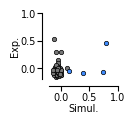

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


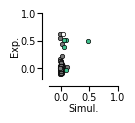

In [60]:
# ==========================
# SCATTER
# ==========================

import matplotlib
import matplotlib.pyplot as plt
import numpy as np

matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = 7


# --------------------------
# 공통 레이아웃
# --------------------------

LEFT = 0.22
RIGHT = 0.98
TOP = 0.95
BOTTOM = 0.22

SCATTER_H = 1


for site in ['tarsal', 'labial']:

    for cond in ['sugar']:#['sugar', 'sugar+geosmin']:

        fig, ax = plt.subplots(
            1, 1,
            figsize=(.9, .9),
            constrained_layout=False
        )

        # --------------------------
        # network 분리
        # --------------------------
        if cond =='sugar':
            cell2color_per_site = cell2color_per_site_sugar
        else:
            cell2color_per_site = cell2color_per_site_geo
            
        in_network = [
            x for x, y
            in cell2color_per_site_sugar[site].items()
            if y != '#777777'
        ]

        not_in_network = [
            x for x, y
            in cell2color_per_site_sugar[site].items()
            if y == '#777777'
        ]


        # --------------------------
        # background neurons
        # --------------------------

        plot_screening_split_condition(
            all_df[site].loc[not_in_network],
            popt[site],
            control_suc_exp[cond][site],
            control_suc_simul[cond][site],
            ax=ax,
            condition=cond,
            cell2color=cell2color_per_site_sugar[site]
        )


        # --------------------------
        # highlighted neurons
        # --------------------------

        plot_screening_split_condition(
            all_df[site].loc[in_network],
            popt[site],
            control_suc_exp[cond][site],
            control_suc_simul[cond][site],
            ax=ax,
            condition=cond,
            cell2color=cell2color_per_site_sugar[site]
        )


        # --------------------------
        # Axis formatting
        # --------------------------

        if cond == 'sugar':

            ax.set_xticks(
                np.arange(0, 1.5, .5)
            )

            ax.set_yticks(
                np.arange(0, 1.5, .5)
            )

            ax.set_xlim([-.2, 1])

            ax.set_ylim([-.2, 1])

        else:

            if site == 'tarsal':
                ax.set_xticks(
                    np.arange(-2, 1.5, .5)
                )

                ax.set_yticks(
                    np.arange(-2, 1.5, .5)
                )
                ax.set_xlim([0, 1.35])

                ax.set_ylim([0, 1.35])

            else:

                ax.set_xticks(
                    np.arange(-2, 1.5, .5)
                )

                ax.set_yticks(
                    np.arange(-2, 1.5, .5)
                )

                ax.set_xlim([0, 1])

                ax.set_ylim([0, 1])


        # --------------------------
        # Labels
        # --------------------------

        ax.set_ylabel('Exp.')

        ax.set_xlabel('Simul.')


        # --------------------------
        # Spine formatting
        # --------------------------

        ax.spines[['top', 'right']].set_visible(False)

        ax.spines['left'].set_position(
            ('outward', 5)
        )

        ax.spines['bottom'].set_position(
            ('outward', 5)
        )


        # --------------------------
        # Aspect ratio
        # --------------------------

#         ax.set_aspect(
#             'equal',
#             adjustable='box'
#         )


        # --------------------------
        # Tick formatting
        # --------------------------

        ax.tick_params(pad=1)

        ax.xaxis.labelpad = 0.5

        ax.yaxis.labelpad = 0.5


        # --------------------------
        # Layout
        # --------------------------

        fig.subplots_adjust(
            left=LEFT,
            right=RIGHT,
            top=TOP,
            bottom=BOTTOM
        )


        # --------------------------
        # Save
        # --------------------------

#         plt.savefig(
#             f'figures/{site}_{cond}_scatter.svg')

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

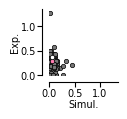

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


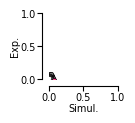

In [61]:
# ==========================
# SCATTER
# ==========================

import matplotlib
import matplotlib.pyplot as plt
import numpy as np

matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = 7


# --------------------------
# 공통 레이아웃
# --------------------------

LEFT = 0.22
RIGHT = 0.98
TOP = 0.95
BOTTOM = 0.22

SCATTER_H = 1


for site in ['tarsal', 'labial']:

    for cond in ['sugar+geosmin']:#['sugar', 'sugar+geosmin']:

        fig, ax = plt.subplots(
            1, 1,
            figsize=(.9, .9),
            constrained_layout=False
        )

        # --------------------------
        # network 분리
        # --------------------------
        if cond =='sugar':
            cell2color_per_site = cell2color_per_site_sugar
        else:
            cell2color_per_site = cell2color_per_site_geo
            
        in_network = [
            x for x, y
            in cell2color_per_site_geo[site].items()
            if y != '#777777'
        ]

        not_in_network = [
            x for x, y
            in cell2color_per_site_geo[site].items()
            if y == '#777777'
        ]


        # --------------------------
        # background neurons
        # --------------------------

        plot_screening_split_condition(
            all_df[site].loc[not_in_network],
            popt[site],
            control_suc_exp[cond][site],
            control_suc_simul[cond][site],
            ax=ax,
            condition=cond,
            cell2color=cell2color_per_site_geo[site]
        )


        # --------------------------
        # highlighted neurons
        # --------------------------

        plot_screening_split_condition(
            all_df[site].loc[in_network],
            popt[site],
            control_suc_exp[cond][site],
            control_suc_simul[cond][site],
            ax=ax,
            condition=cond,
            cell2color=cell2color_per_site_geo[site]
        )


        # --------------------------
        # Axis formatting
        # --------------------------

        if cond == 'sugar':

            ax.set_xticks(
                np.arange(0, 1.5, .5)
            )

            ax.set_yticks(
                np.arange(0, 1.5, .5)
            )

            ax.set_xlim([-.2, 1])

            ax.set_ylim([-.2, 1])

        else:

            if site == 'tarsal':
                ax.set_xticks(
                    np.arange(-2, 1.5, .5)
                )

                ax.set_yticks(
                    np.arange(-2, 1.5, .5)
                )
                ax.set_xlim([0, 1.35])

                ax.set_ylim([0, 1.35])

            else:

                ax.set_xticks(
                    np.arange(-2, 1.5, .5)
                )

                ax.set_yticks(
                    np.arange(-2, 1.5, .5)
                )

                ax.set_xlim([0, 1])

                ax.set_ylim([0, 1])


        # --------------------------
        # Labels
        # --------------------------

        ax.set_ylabel('Exp.')

        ax.set_xlabel('Simul.')


        # --------------------------
        # Spine formatting
        # --------------------------

        ax.spines[['top', 'right']].set_visible(False)

        ax.spines['left'].set_position(
            ('outward', 5)
        )

        ax.spines['bottom'].set_position(
            ('outward', 5)
        )


        # --------------------------
        # Aspect ratio
        # --------------------------

#         ax.set_aspect(
#             'equal',
#             adjustable='box'
#         )


        # --------------------------
        # Tick formatting
        # --------------------------

        ax.tick_params(pad=1)

        ax.xaxis.labelpad = 0.5

        ax.yaxis.labelpad = 0.5


        # --------------------------
        # Layout
        # --------------------------

        fig.subplots_adjust(
            left=LEFT,
            right=RIGHT,
            top=TOP,
            bottom=BOTTOM
        )


        # --------------------------
        # Save
        # --------------------------

#         plt.savefig(
#             f'figures/{site}_{cond}_scatter.svg')